<a href="https://colab.research.google.com/github/bestianello88/ANALISI/blob/main/07_Analisi_Descrittive_Focus_sull'Italia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

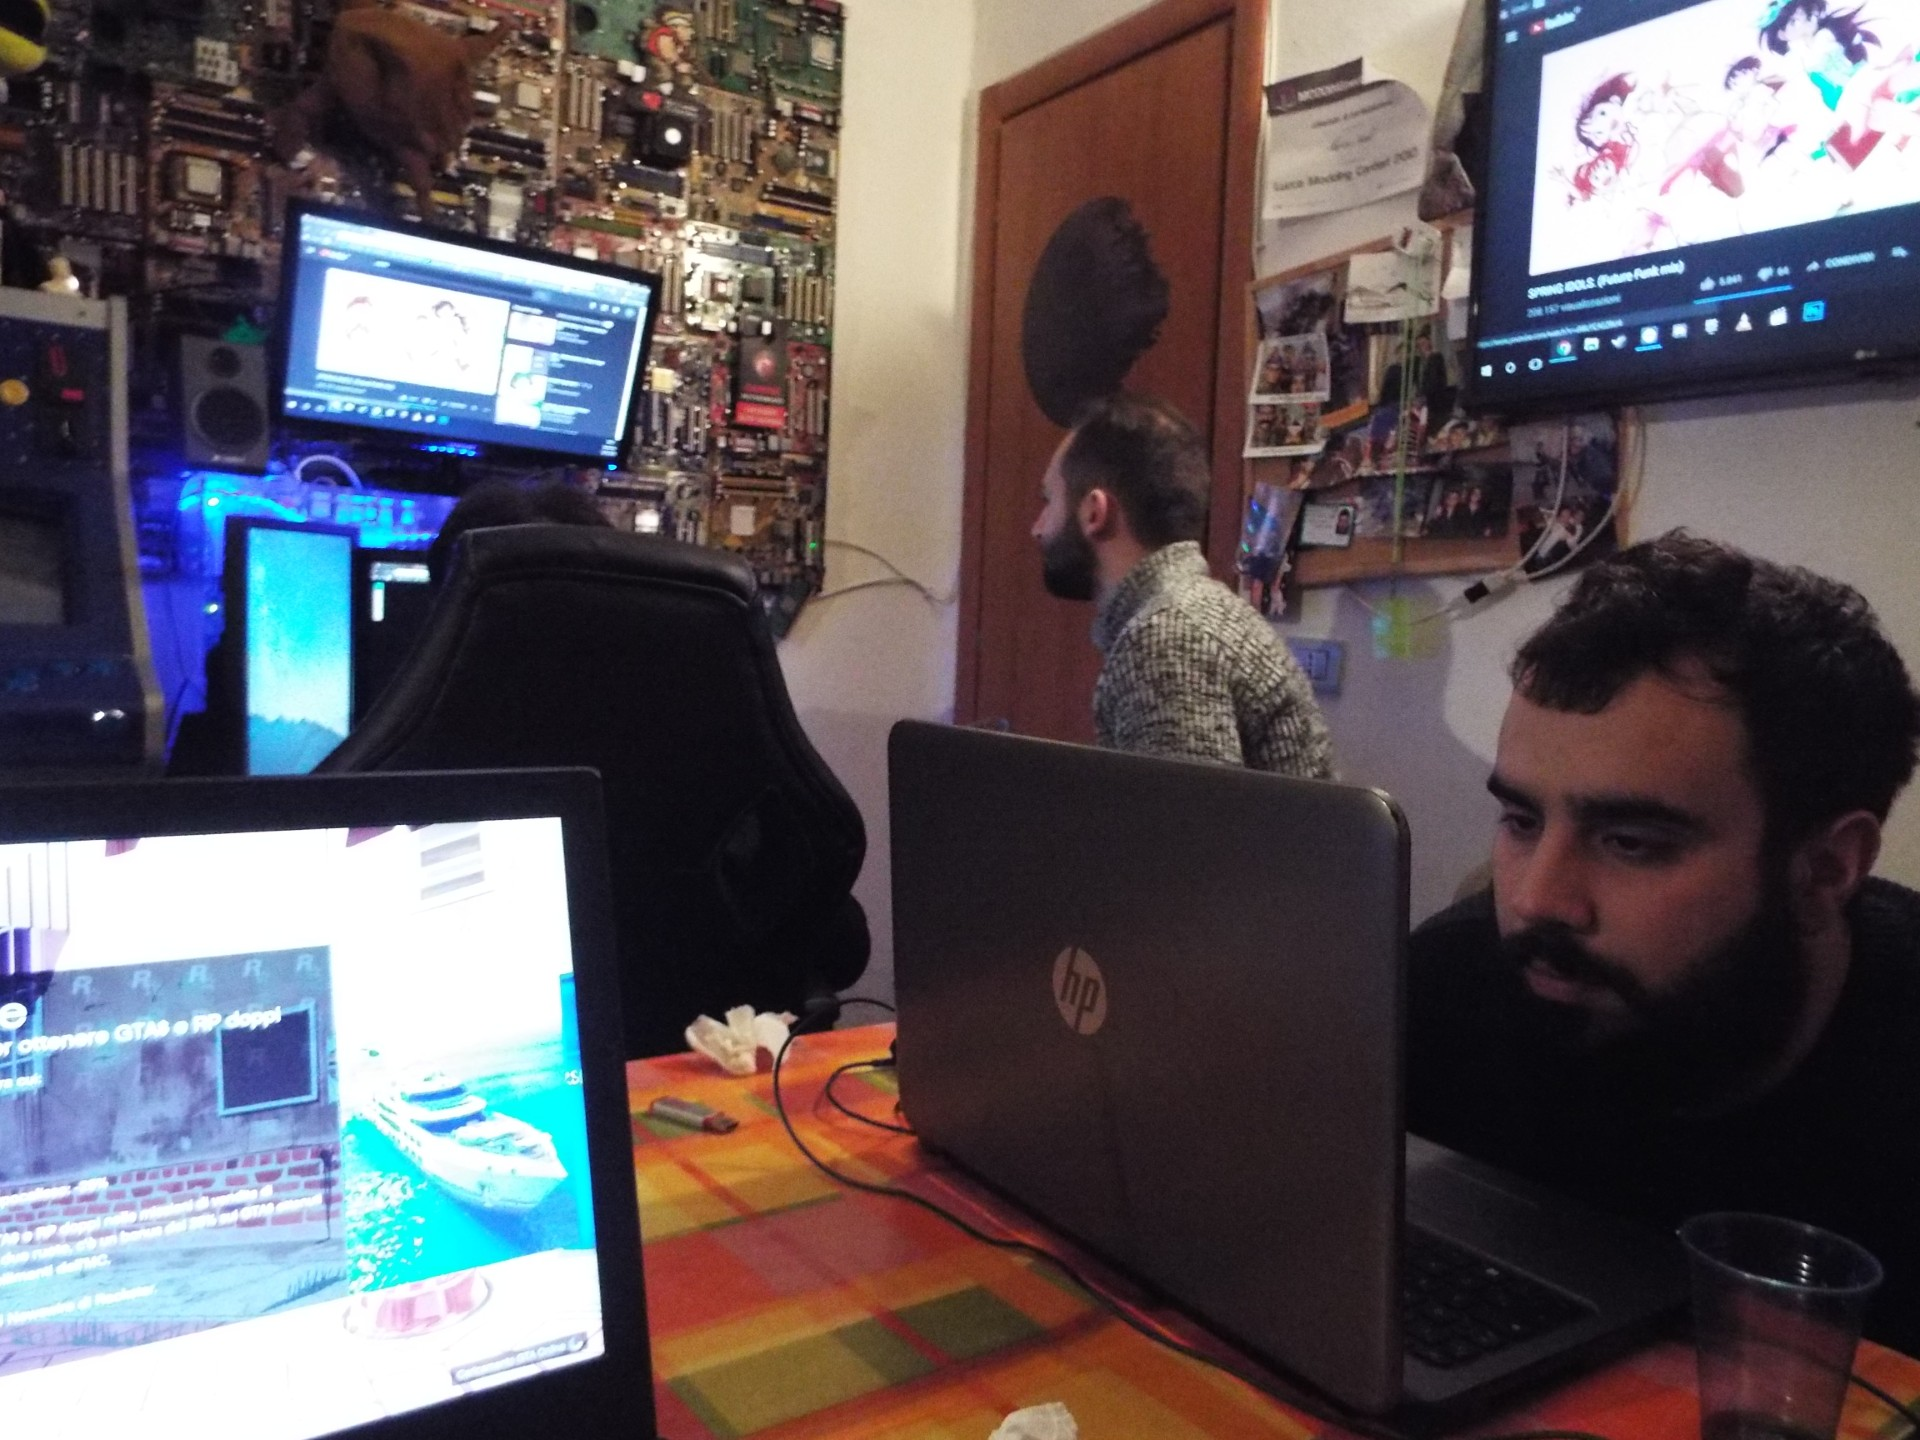

# **07 - Analisi Descrittive: Focus sull'Italia**
# Trend Totale del’Emissione dei Gas Serra dal 1990 al 2023

Dovendo lavorare solo su dati italiani, ciò che dobbiamo fare è prima di tutto filtrare questi dati, per ogni gas serra.

Una buona idea, inoltre, potrebbe essere quella di creare/modificare un DataFrame che meglio rispecchi le nostre necessità.

Quindi, un paio di dritte:
Filtrare i dati di ogni Gas Serra per l’Italia;

Migliorare la struttura dati
Cancelliamo la colonna Country, che diventa obsoleta;

Creiamo la colonna Gas dove avremo un dato categorico che rappresenta, per l’appunto, il nome del gas analizzato;

Creiamo un DataFrame per gas;

Mergiamo i vari DataFrame creati.

Calcoliamo il totale delle emissioni e visualizziamo a schermo.

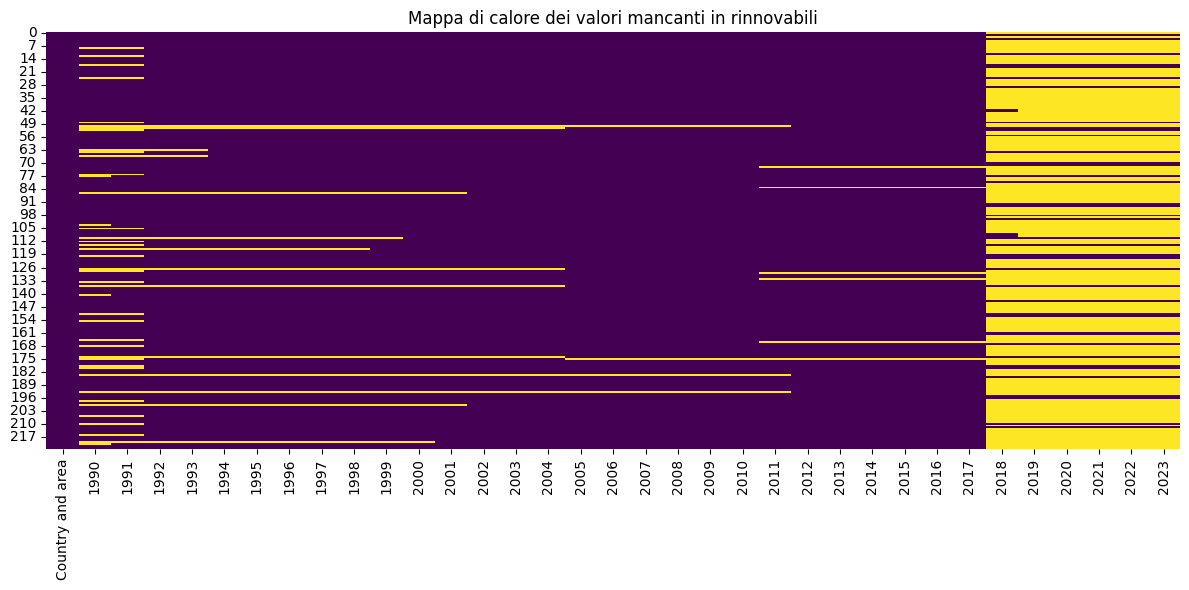

In [ ]:
# FILTRAGGIO DI OGNI GAS SERRA PER L'ITALIA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

from google.colab import drive

# Mount Google Drive
#drive.mount('/content/drive')

# Define the base path for your files
base_path = '/content/drive/MyDrive/Colab Notebooks/PROGETTO FINALE/'

# Load CSV files usando pd.read_csv
dfch4 = pd.read_csv(base_path + 'CH4_Emissions.csv')
dfco2 = pd.read_csv(base_path + 'CO2_Emissions.csv')
dfghg = pd.read_csv(base_path + 'GHG_Emissions.csv')
dfn2o = pd.read_csv(base_path + 'N2O_Emissions.csv')
dfnox = pd.read_csv(base_path + 'NOx_Emissions.csv')
dfso2 = pd.read_csv(base_path + 'SO2_emissions.csv')
dfrinnovabili = pd.read_csv(base_path + 'Renewable_Electricity_Production_Dataset.csv')

print ('\n')

plt.figure(figsize=(12,6))
sns.heatmap(dfrinnovabili.isnull(), cmap='viridis', cbar=False)
plt.title('Mappa di calore dei valori mancanti in rinnovabili')
plt.tight_layout()
plt.show()

print('\n')

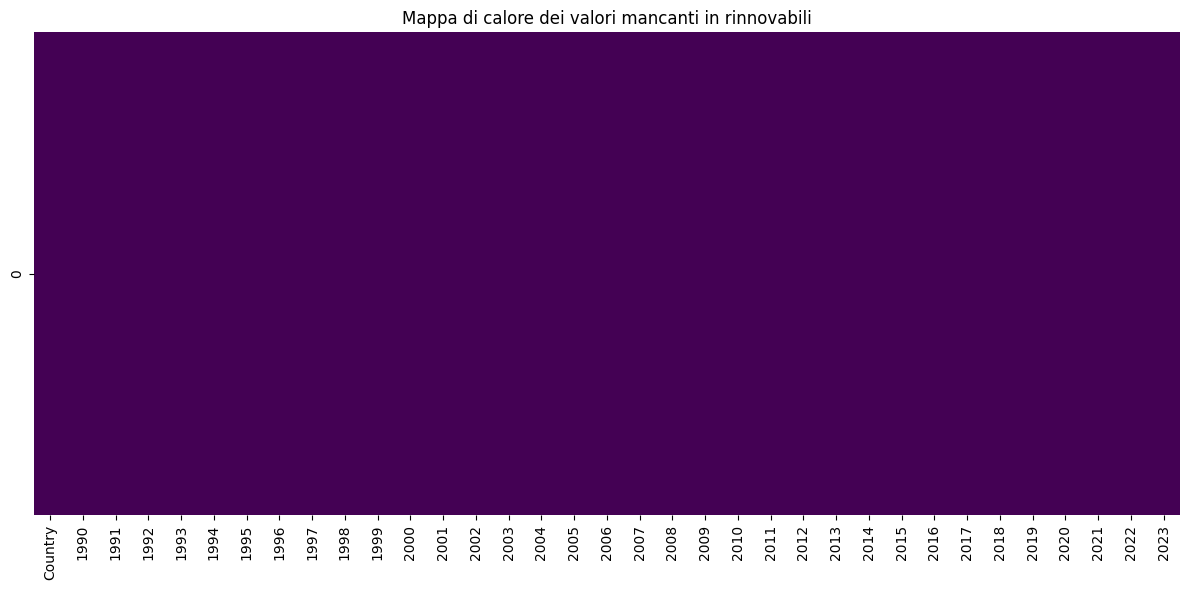

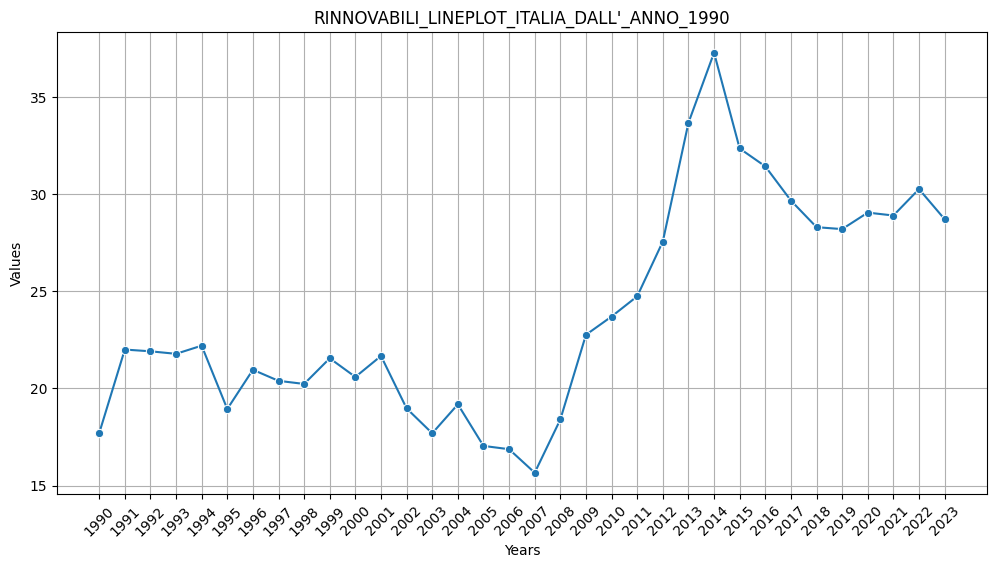

In [ ]:
from typing import Literal
IT = [
'Italy',
]

# FUNZIONE CHE RESTITUISCE SOLO ITALIA DA APPLICARE A TUTTI I DF

def filter_eu_countries(df):
    """
    Restituisce un nuovo Dataframe con solo i paesi dell'Unione Europea

    Args:
        df (DataFrame): Il DataFrame da filtrare

    Returns:
        DataFrame: Nuovo DataFrame con solo i paesi dell'Unione Europea
    """
    return df[df['Country'].isin(IT)].reset_index(drop=True)

# Rename 'Country and area' to 'Country' in dfrinnovabili before filtering

dfrinnovabili = dfrinnovabili.rename(columns={'Country and area': 'Country'})

filtered_rinnovabili= filter_eu_countries(dfrinnovabili)

# DATASET_ITALIANI

it_dfch4 = filter_eu_countries(dfch4)
it_dfco2 = filter_eu_countries(dfco2)
it_dfghg = filter_eu_countries(dfghg)
it_dfn2o = filter_eu_countries(dfn2o)
it_dfnox = filter_eu_countries(dfnox)
it_dfso2 = filter_eu_countries(dfso2)

it_dfrinnovabili = filter_eu_countries(dfrinnovabili) #RINNOVABILI PER ORA LO OMETTIAMO

it_dfrinnovabili_copy = it_dfrinnovabili.copy()

def convert_values_to_numeric(df):
    """
    Converte i valori di tutte le colonne di un DataFrame in tipo numerico.
    I valori non convertibili verranno sostituiti con NaN.

    Args:
        df(DataFrame): Il DataFrame da analizzare.

    Returns:
        DataFrame: Una copia del DataFrame con valori numerici convertiti.
        list: Lista delle colonne convertite.
    """
    # Creo una copia per evitare modifiche al DataFrame originale
    temp_df = df.copy ()
    numeric_cols = []

    # Faccio una iterazione su tutte le colonne e le converte in numeriche
    for col in temp_df.columns:
        if col != 'Country':
            temp_df[col] = pd.to_numeric(temp_df[col], errors='coerce')
            numeric_cols.append(col)

    return temp_df, numeric_cols


it_dfrinnovabili_numeric_df, it_dfrinnovabili_years = convert_values_to_numeric(it_dfrinnovabili_copy)


print ('\n')

plt.figure(figsize=(12,6))
sns.heatmap(it_dfrinnovabili_numeric_df.isnull(), cmap='viridis', cbar=False)
plt.title('Mappa di calore dei valori mancanti in rinnovabili')
plt.tight_layout()
plt.show()

# RINNOVABILI_LINEPLOT_FINITO

print('\n')
plt.figure(figsize=(12,6))
sns.lineplot(x=it_dfrinnovabili_years, y=it_dfrinnovabili_numeric_df[it_dfrinnovabili_years].iloc[0], marker='o')
plt.title("RINNOVABILI_LINEPLOT_ITALIA_DALL'_ANNO_1990")
plt.xlabel('Years', loc='center')
plt.xticks(rotation=45)
plt.ylabel('Values')
plt.grid(True)
plt.show()

print('\n')

# Convert gas dataframes to numeric and plot heatmaps

# NON CI SONO VALORI MANCANTI, POSSIAMO PROCEDERE

# FUNZIONE CHE ELIMINA LA COLONNA COUNTRY DA OGNI DF

def drop_country(df):

  """
  Elimina la colonna 'Country' da un DataFrame.

  Args:
      df (DataFrame): Il DataFrame da cui eliminare la colonna 'Country'.

  Returns:
      DataFrame: Nuovo DataFrame con la colonna 'Country' eliminata.

  """

  if 'Country' in df.columns:
    return df.drop('Country', axis=1)
  return df

it_dfch4_copy= it_dfch4.copy()
it_dfco2_copy= it_dfco2.copy()
it_dfghg_copy= it_dfghg.copy()
it_dfn2o_copy= it_dfn2o.copy()
it_dfnox_copy= it_dfnox.copy()
it_dfso2_copy= it_dfso2.copy()


print('\n')

# **MANIPOLAZIONE DEI DATI**



Head of N2O long format:
   Year  Value  Gas
0  1990  87.37  N2O
1  1991  90.78  N2O
2  1992  89.22  N2O
3  1993  90.71  N2O
4  1994  88.94  N2O


Head of combined emissions DataFrame:
    Year      Value  Gas
0   1990    1929.90  CH4
1   1991    1965.06  CH4
2   1992    1959.08  CH4
3   1993    1971.34  CH4
4   1994    1988.34  CH4
5   1995    2013.03  CH4
6   1996    2032.67  CH4
7   1997    2054.56  CH4
8   1998    2035.22  CH4
9   1999    2034.16  CH4
10  2000    2030.65  CH4
11  2001    2034.75  CH4
12  2002    1969.60  CH4
13  2003    1977.85  CH4
14  2004    1913.15  CH4
15  2005    1933.13  CH4
16  2006    1882.59  CH4
17  2007    1910.54  CH4
18  2008    1893.11  CH4
19  2009    1891.69  CH4
20  2010    1879.20  CH4
21  2011    1822.78  CH4
22  2012    1846.73  CH4
23  2013    1790.83  CH4
24  2014    1756.19  CH4
25  2015    1755.34  CH4
26  2016    1735.97  CH4
27  2017    1746.32  CH4
28  2018    1721.31  CH4
29  2019    1215.95  CH4
30  2020     766.13  CH4
31  2021     

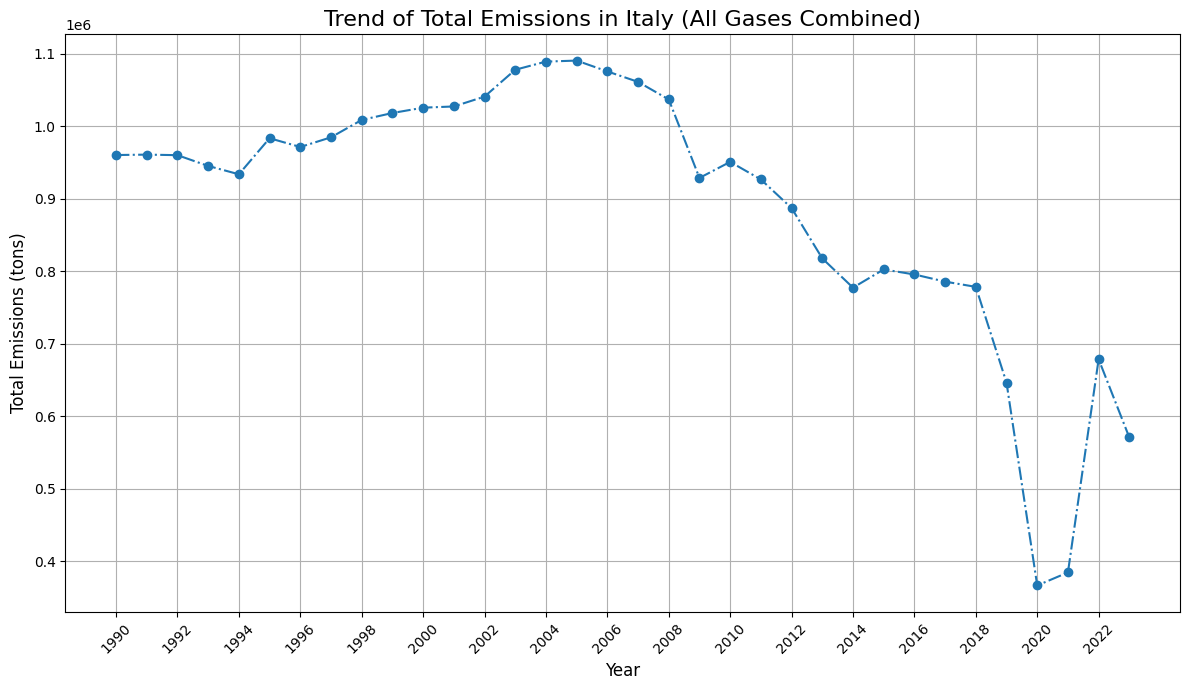

In [ ]:


# PORTO DA UN FORMATO LONG AD UN FORMATO WIDE IL MIO DATASET

# CREAZIONE DI UNA VARIABILE PER GLI ANNI (lista)

def melt_and_add_gas(df, gas_name):

    df_melted = df.melt(var_name='Year', value_name='Value')
    df_melted['Gas'] = gas_name
    df_melted['Year'] = pd.to_numeric(df_melted['Year'])
    return df_melted

# Convert gas dataframes to numeric, drop 'Country', and then melt
it_dfch4_numeric_converted, _ = convert_values_to_numeric(it_dfch4.copy())
it_dfch4_numeric = drop_country(it_dfch4_numeric_converted)
it_dfch4_long = melt_and_add_gas(it_dfch4_numeric, 'CH4')

it_dfco2_numeric_converted, _ = convert_values_to_numeric(it_dfco2.copy())
it_dfco2_numeric = drop_country(it_dfco2_numeric_converted)
it_dfco2_long = melt_and_add_gas(it_dfco2_numeric, 'CO2')

it_dfghg_numeric_converted, _ = convert_values_to_numeric(it_dfghg.copy())
it_dfghg_numeric = drop_country(it_dfghg_numeric_converted)
it_dfghg_long = melt_and_add_gas(it_dfghg_numeric, 'GHG')

it_dfn2o_numeric_converted, _ = convert_values_to_numeric(it_dfn2o.copy())
it_dfn2o_numeric = drop_country(it_dfn2o_numeric_converted)
it_dfn2o_long = melt_and_add_gas(it_dfn2o_numeric, 'N2O')

it_dfnox_numeric_converted, _ = convert_values_to_numeric(it_dfnox.copy())
it_dfnox_numeric = drop_country(it_dfnox_numeric_converted)
it_dfnox_long = melt_and_add_gas(it_dfnox_numeric, 'NOx')

it_dfso2_numeric_converted, _ = convert_values_to_numeric(it_dfso2.copy())
it_dfso2_numeric = drop_country(it_dfso2_numeric_converted)
it_dfso2_long = melt_and_add_gas(it_dfso2_numeric, 'SO2')

# Mergiamo i vari DataFrame creati in uno singolo

all_gas_emissions_df = pd.concat([
    it_dfch4_long,
    it_dfco2_long,
    it_dfghg_long,
    it_dfn2o_long,
    it_dfnox_long,
    it_dfso2_long
], ignore_index=True)

print('\n')
print("Head of N2O long format:")
print(it_dfn2o_long.head())
print('\n')
print("Head of combined emissions DataFrame:")
print(all_gas_emissions_df.head(40))
print('\n')
print("Info of N2O long format:")
print(it_dfn2o_long.info())
print('\n')
print("Info of combined emissions DataFrame:")
all_gas_emissions_df.info()

# Calculate total emissions per year

total_emissions_per_year = all_gas_emissions_df.groupby('Year')['Value'].sum().reset_index()

plt.figure(figsize=(12, 7))

plt.plot(
    total_emissions_per_year['Year'],    # X-axis: Year
    total_emissions_per_year['Value'],   # Y-axis: Total Value
    marker='o', linestyle='-.'
)

plt.title('Trend of Total Emissions in Italy (All Gases Combined)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Emissions (tons)', fontsize=12)

years_for_xticks = total_emissions_per_year['Year']
plt.xticks(np.arange(years_for_xticks.min(), years_for_xticks.max() + 1, step=2), rotation=45)
plt.yticks(fontsize=10)

plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Calcola il valore massimo per ciascun gas
df_max_values = all_gas_emissions_df.groupby('Gas')['Value'].max().reset_index()

# Rinomina le colonne (già impostate correttamente da reset_index() ma mantenuto per chiarezza)
df_max_values.columns = ['Gas', 'Valore massimo']


# Visualizza il nuovo dataframe
print(df_max_values)

# Creo un nuovo DataFrame, copiando l'originale all_gas_emissions_df per lavorare con i dati completi
df_italy = all_gas_emissions_df.copy()

# Rimuovere la CO2 dal DataFrame
df_no_co2 = df_italy[df_italy["Gas"] != "CO2"]

df_no_co2_ghg = df_no_co2[df_no_co2["Gas"] != "GHG"]

all_gas_emissions_df_copy = all_gas_emissions_df.copy

df_no_co2_ghg_wide = df_no_co2_ghg.pivot(index='Year', columns='Gas', values='Value')

# Il DataFrame è già in formato lungo, non è necessaria un'ulteriore operazione di melt

# Valutiamo il risultato

print("\nHead of DataFrame excluding CO2 and GHG:")

print(df_no_co2_ghg.nunique())

print('\n')

print(df_no_co2_ghg.head())

   Gas  Valore massimo
0  CH4         2054.56
1  CO2       500005.68
2  GHG       586529.47
3  N2O           99.02
4  NOx         2233.25
5  SO2         1783.86

Head of DataFrame excluding CO2 and GHG:
Year      34
Value    136
Gas        4
dtype: int64


   Year    Value  Gas
0  1990  1929.90  CH4
1  1991  1965.06  CH4
2  1992  1959.08  CH4
3  1993  1971.34  CH4
4  1994  1988.34  CH4


# Trend del’Emissione dei Gas Serra senza CO2 e GHG

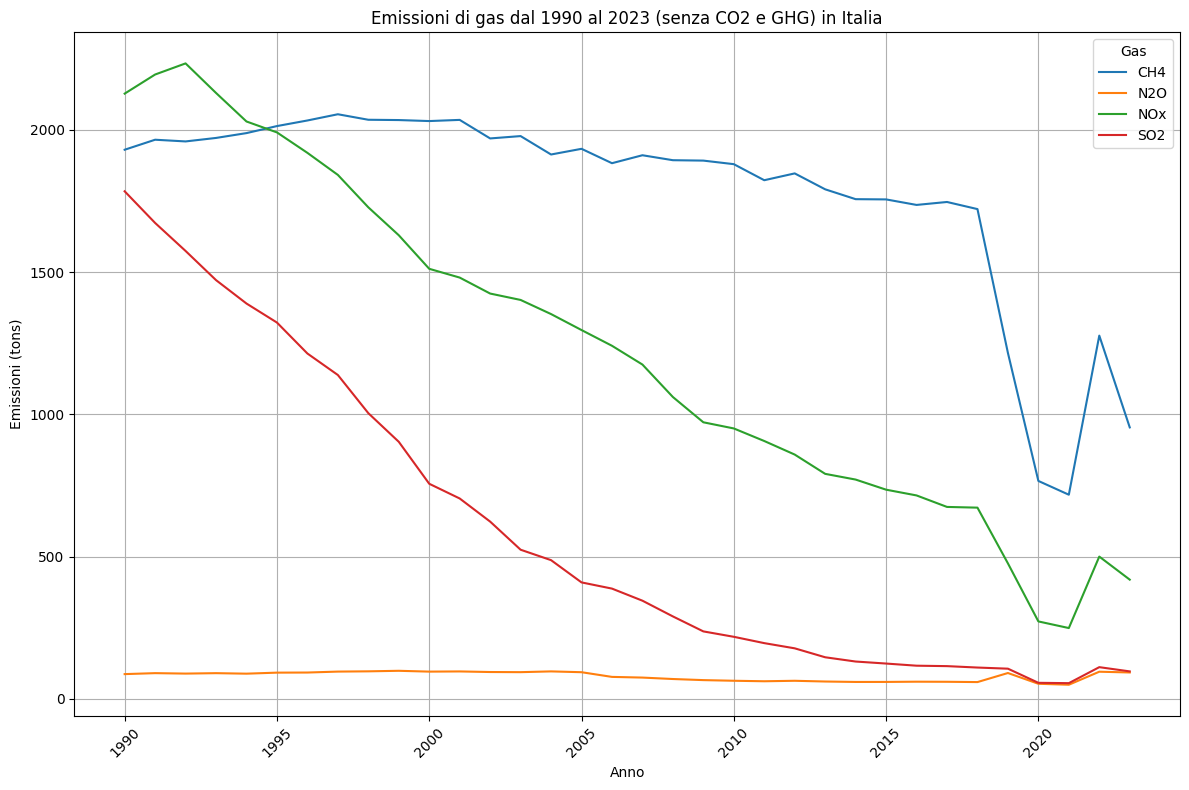

In [ ]:


# Creare il diagramma a linee
plt.figure(figsize=(12, 8))
for gas in df_no_co2_ghg ["Gas"].unique():
    gas_data = df_no_co2_ghg [df_no_co2_ghg ["Gas"] == gas]
    plt.plot(gas_data["Year"], gas_data["Value"], label=gas)

# Configurazione del grafico
plt.title("Emissioni di gas dal 1990 al 2023 (senza CO2 e GHG) in Italia")
plt.xlabel("Anno")
plt.ylabel("Emissioni (tons)")
plt.legend(title="Gas")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **Trend del’Utilizzo di Energie Rinnovabili in Italia dal 1990 al 2023**

Adesso è arrivato il momento di mostrare a schermo l’utilizzo delle Energie Rinnovabili in Italia dal 1990 al 2023.
I passaggi saranno piuttosto simili a quelli effettuati in precedenza ma sicuramente più semplici, in quanto dovremo lavorare solo con un
DataFrame.
Per ottenere il nostro risultato, dovremo:
Filtrare i dati italiani dai dati sulle energie rinnovabili;
Ricordarci di trasformare gli anni in numeri;
Creare un grafico.

In [ ]:
df_renewable = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/CSV GENERATI/cleaned_df_renewable.csv')

df_renewable_ita = df_renewable[df_renewable['Country'] == 'Italy']

# Per accorpare gli anni porto il dataset in formato lungo con .melt

df_renewable_ita_copy = df_renewable_ita.copy()

df_renewable_ita_copy.columns = ['Country'] + [int(col) for col in df_renewable_ita_copy.columns[1:]]

df_renewable_ita_melted = df_renewable_ita_copy.melt(id_vars=['Country'], var_name='Year', value_name='Value')


print(df_renewable.info())
print(df_renewable_ita.info())
print(df_renewable_ita_melted.head())

plt.figure(figsize=(12, 8))
plt.plot(df_renewable_ita_melted['Year'], df_renewable_ita_melted['Value'], marker='o', linestyle='-')
plt.title('RINNOVABILI_ITA_DAL_2005_AL_2023')
plt.xlabel('Year')
plt.ylabel('Value')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



# **Confronto con la media dell’Unione Europea dal 2005 al 2023**
Un'analisi utile per comprendere l'operato dell'Italia in questa situazione è confrontare la sua risposta con la media dei dati di tutta l'Unione
Europea.
Un paio di dritte su quello che dobbiamo fare:
per un’analisi più accurata, dobbiamo ricordare che molti dati dell’UE pre-2005 sono
NaN . Lavoreremo quindi sui dati dal 2005 in poi;
dobbiamo calcolare la media dell’utilizzo delle energie rinnovabili in tutta l’UE per ogni anno;
dobbiamo ricordarci di convertire gli anni in dato numerico;
dobbiamo creare un grafico di confronto

In [ ]:
df_renewable.head()

# Calcola la media delle colonne numeriche
df_eu_mean = df_renewable.iloc[:, 1:].mean(axis=0).reset_index()

df_ita_mean = df_renewable_ita.iloc[:, 1:].mean(axis=0).reset_index()

# Rinomina le colonne del risultato
df_eu_mean.columns = ['Year', 'Mean Renewable Energy (%)']

# Visualizza il risultato
print(df_eu_mean.head(20))

df_ita_mean.columns = ['Year', 'Mean Renewable Energy (%)']
print(df_ita_mean.head(20))

print('\n')

df_italy_renewable =  df_renewable_ita.copy()

# Conversione degli anni in numerico
years = df_italy_renewable.columns[1:].astype(int)
italy_values = df_italy_renewable.iloc[0, 1:].astype(float)
eu_values = df_eu_mean['Mean Renewable Energy (%)']

# Grafico
plt.figure(figsize=(12, 6))
plt.plot(years, eu_values, label='EU Mean', linestyle='--')
plt.plot(years, italy_values, label='Italy', marker='o')

# Configurazione
plt.title('Comparison of Renewable Energy Production in Italy vs. EU Mean')
plt.xlabel('Year')
plt.ylabel('Renewable Energy Production (%)')
plt.legend()
plt.grid(True)
plt.show()